In [1]:
!ls -lh ~/work/data_augmentation/data

total 1.5G
drwxrwsr-x 122 jovyan users 4.0K Oct  9  2011 Images
-rw-rw-r--   1 jovyan users 757M Oct 20  2011 images.tar
-rw-rw-r--   1 jovyan users 757M Oct 20  2011 images.tar.1


In [2]:
!ls ~/work/data_augmentation/data/Images | head

n02085620-Chihuahua
n02085782-Japanese_spaniel
n02085936-Maltese_dog
n02086079-Pekinese
n02086240-Shih-Tzu
n02086646-Blenheim_spaniel
n02086910-papillon
n02087046-toy_terrier
n02087394-Rhodesian_ridgeback
n02088094-Afghan_hound


In [3]:
!find ~/work/data_augmentation/data/Images -type f | wc -l

20580


데이터셋 업로드 관련 정리
Stanford Dogs Dataset은 이미지 수가 많고 용량이 크기 때문에 외부에 직접 업로드하지 않고, 실습 환경 내부의 ~/work/data_augmentation/data 경로에 저장하여 사용한다.

실습에서는 데이터셋 전체를 제출하는 것이 아니라, 데이터 다운로드 여부, 압축 해제 여부, ImageFolder 로딩 결과, DataLoader 샘플 출력 결과를 통해 데이터 준비가 정상적으로 되었는지 확인한다.

In [5]:
import torch
import torchvision
import numpy as np
import matplotlib.pyplot as plt
import os

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split
import torchvision.transforms as transforms

print("라이브러리 준비 완료")

라이브러리 준비 완료


In [6]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [7]:
dataset_dir = os.path.expanduser("~/work/data_augmentation/data/Images/")

transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

full_dataset = ImageFolder(root=dataset_dir, transform=transform)

print("전체 데이터 수:", len(full_dataset))
print("클래스 수:", len(full_dataset.classes))
print("클래스 예시:", full_dataset.classes[:5])

전체 데이터 수: 20580
클래스 수: 120
클래스 예시: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu']


In [8]:
total_size = len(full_dataset)

train_size = int(0.583 * total_size)
test_size = total_size - train_size

ds_train, ds_test = random_split(full_dataset, [train_size, test_size])

print("Train 데이터 수:", len(ds_train))
print("Test 데이터 수:", len(ds_test))

Train 데이터 수: 11998
Test 데이터 수: 8582


In [9]:
train_loader = DataLoader(ds_train, batch_size=32, shuffle=True)
test_loader = DataLoader(ds_test, batch_size=32, shuffle=False)

ds_info = {
    "num_classes": len(full_dataset.classes),
    "class_names": full_dataset.classes
}

print("DataLoader 준비 완료")
print("클래스 수:", ds_info["num_classes"])

DataLoader 준비 완료
클래스 수: 120


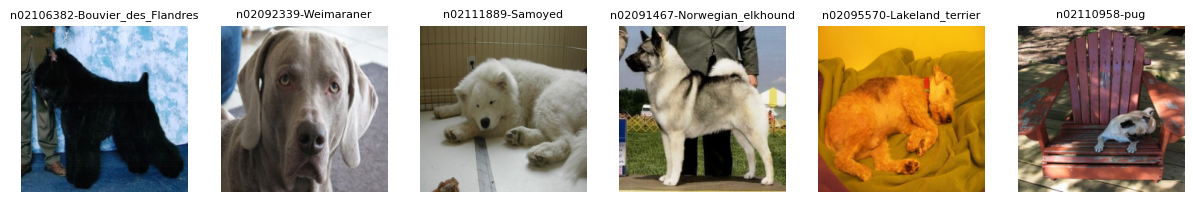

In [10]:
def show_examples(data_loader, class_names, num_images=6):
    data_iter = iter(data_loader)
    images, labels = next(data_iter)

    fig, axes = plt.subplots(1, num_images, figsize=(15, 5))

    for i in range(num_images):
        image = images[i].permute(1, 2, 0).numpy()
        image = (image * 0.5) + 0.5
        image = np.clip(image, 0, 1)

        axes[i].imshow(image)
        axes[i].axis("off")
        axes[i].set_title(class_names[labels[i].item()], fontsize=8)

    plt.show()

show_examples(train_loader, ds_info["class_names"])

데이터 불러오기 결과 정리
Stanford Dogs Dataset의 압축을 해제한 뒤 ImageFolder를 사용하여 데이터셋을 불러왔다.
전체 이미지 수는 20,580개이고, 클래스 수는 120개로 확인되었다.

이미지는 모델 입력 크기에 맞게 224x224로 조정하고, Tensor로 변환한 뒤 Normalize를 적용하였다.
이후 random_split()을 사용하여 train 데이터와 test 데이터로 나누고, DataLoader를 통해 batch 단위로 불러올 수 있도록 준비하였다.

샘플 이미지를 출력하여 이미지와 라벨이 정상적으로 연결되어 있음을 확인하였다.

## 2. Augmentation 적용하기

앞 단계에서는 Stanford Dogs Dataset을 불러오고, train/test 데이터로 나누어 DataLoader를 준비하였다.  
이번 단계에서는 train 데이터에만 기본적인 augmentation을 적용해본다.

모델 학습에서는 train 데이터와 test 데이터의 전처리를 다르게 설정해야 한다.  
train 데이터는 모델이 다양한 상황을 학습하도록 랜덤 augmentation을 적용할 수 있다.  
반면 test 데이터는 모델의 실제 성능을 공정하게 평가해야 하므로 랜덤 augmentation을 적용하지 않고, 일정한 전처리만 적용한다.

### 핵심 정리

- Train 데이터: RandomResizedCrop, RandomHorizontalFlip, ColorJitter 등 랜덤 augmentation 적용
- Test 데이터: Resize, ToTensor, Normalize 등 고정 전처리만 적용

In [11]:
train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),              # 랜덤하게 crop 후 224x224로 resize
    transforms.RandomHorizontalFlip(p=0.5),         # 50% 확률로 좌우 반전
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),                                             # 밝기, 대비, 채도, 색조 변화
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),                 # 고정 크기 변환
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("train_transform과 test_transform 준비 완료")

train_transform과 test_transform 준비 완료


### train_transform과 test_transform의 차이

`train_transform`에는 랜덤 augmentation을 포함하였다.  
`RandomResizedCrop`, `RandomHorizontalFlip`, `ColorJitter`를 사용하여 이미지의 위치, 방향, 색감이 달라지도록 만들었다.  
이를 통해 모델이 특정 이미지의 형태나 배경만 외우지 않고 더 다양한 상황을 학습할 수 있다.

반면 `test_transform`에는 랜덤 augmentation을 넣지 않았다.  
test 데이터는 모델의 실제 성능을 공정하게 평가하기 위한 데이터이므로, 매번 결과가 달라지는 랜덤 변형을 적용하지 않는다.

즉, train 데이터는 다양하게 변형하고, test 데이터는 일정하게 유지한다.

In [12]:
dataset_dir = os.path.expanduser("~/work/data_augmentation/data/Images/")

train_full_dataset = ImageFolder(root=dataset_dir, transform=train_transform)
test_full_dataset = ImageFolder(root=dataset_dir, transform=test_transform)

total_size = len(train_full_dataset)
train_size = int(0.583 * total_size)
test_size = total_size - train_size

# 같은 비율로 train/test 분리
ds_train_aug, _ = random_split(train_full_dataset, [train_size, test_size])
_, ds_test_basic = random_split(test_full_dataset, [train_size, test_size])

train_aug_loader = DataLoader(ds_train_aug, batch_size=32, shuffle=True)
test_basic_loader = DataLoader(ds_test_basic, batch_size=32, shuffle=False)

print("Augmentation 적용 train_loader 준비 완료")
print("기본 전처리 test_loader 준비 완료")
print("Train 데이터 수:", len(ds_train_aug))
print("Test 데이터 수:", len(ds_test_basic))

Augmentation 적용 train_loader 준비 완료
기본 전처리 test_loader 준비 완료
Train 데이터 수: 11998
Test 데이터 수: 8582


### 주의점

실습에서는 train용 transform과 test용 transform을 각각 적용하기 위해 데이터셋을 다시 만들었다.  
다만 엄밀한 비교 실험에서는 train/test split이 동일하게 유지되어야 한다.  
그래야 augmentation 적용 여부만 다르고, 데이터 구성은 같은 상태에서 공정하게 비교할 수 있다.

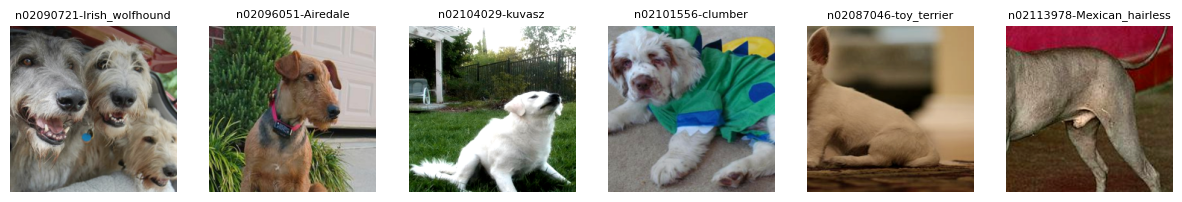

In [13]:
show_examples(train_aug_loader, ds_info["class_names"], num_images=6)

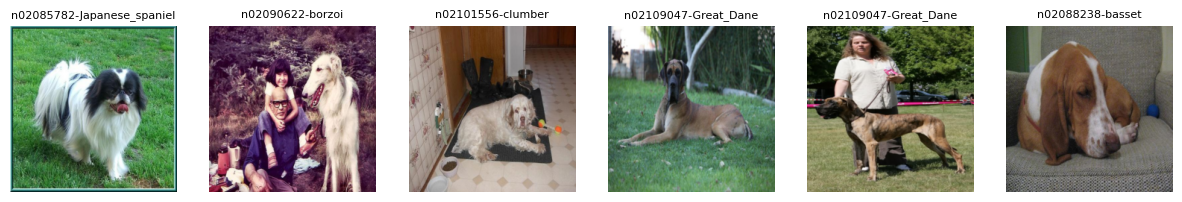

In [14]:
show_examples(test_basic_loader, ds_info["class_names"], num_images=6)

### Augmentation 적용 결과 관찰

train 데이터에는 RandomResizedCrop, RandomHorizontalFlip, ColorJitter가 적용되므로 이미지의 위치, 방향, 색감이 다양하게 바뀔 수 있다.  
이를 통해 모델은 강아지가 항상 같은 위치나 같은 조명에서만 등장한다고 외우지 않고, 다양한 상황에서도 견종을 구분하는 특징을 학습할 수 있다.

반면 test 데이터에는 랜덤 augmentation을 적용하지 않았다.  
test 데이터는 모델 성능을 평가하기 위한 데이터이므로, 매번 달라지는 랜덤 변형 없이 고정된 전처리만 적용해야 한다.

예상 문제
문제 1. train 데이터에는 augmentation을 적용하고 test 데이터에는 적용하지 않는 이유는?
정답: train 데이터는 모델이 다양한 상황을 학습하도록 하기 위해 augmentation을 적용할 수 있지만, test 데이터는 모델의 실제 성능을 공정하게 평가해야 하므로 랜덤 augmentation을 적용하지 않는다.

문제 2. RandomHorizontalFlip(p=0.5)의 의미는?
정답: 50% 확률로 이미지를 좌우 반전한다는 의미이다.

문제 3. ColorJitter는 어떤 변화를 주는 augmentation인가?
정답: 이미지의 밝기, 대비, 채도, 색조를 랜덤하게 바꾸는 augmentation이다.

3. 비교 실험하기
이번 단계에서는 Augmentation을 적용한 경우와 적용하지 않은 경우를 비교할 수 있도록 DataLoader를 준비한다.

앞에서는 train 데이터에 RandomResizedCrop, RandomHorizontalFlip, ColorJitter 등을 적용하였다.
하지만 augmentation의 효과를 확인하려면 augmentation을 적용하지 않은 학습 데이터와 적용한 학습 데이터를 비교해야 한다.

따라서 이번 단계에서는 다음 두 가지 train_loader를 준비한다.

기본 전처리만 적용한 train_loader
Augmentation을 적용한 train_loader
test_loader는 공정한 평가를 위해 두 실험 모두 동일하게 사용한다.

In [15]:
basic_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

aug_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("기본 전처리, Augmentation 전처리, Test 전처리 준비 완료")

기본 전처리, Augmentation 전처리, Test 전처리 준비 완료


### 전처리 방식 정리

`basic_train_transform`은 augmentation을 적용하지 않고 Resize, ToTensor, Normalize만 수행한다.  
`aug_train_transform`은 RandomResizedCrop, RandomHorizontalFlip, ColorJitter를 추가하여 train 데이터에 랜덤 변형을 적용한다.  
`test_transform`은 평가용 데이터에 사용하는 전처리로, 랜덤 변형 없이 Resize, ToTensor, Normalize만 수행한다.

비교 실험의 핵심은 train 데이터의 augmentation 적용 여부만 다르게 하고, test 데이터는 동일하게 유지하는 것이다.

In [16]:
dataset_dir = os.path.expanduser("~/work/data_augmentation/data/Images/")

basic_full_dataset = ImageFolder(root=dataset_dir, transform=basic_train_transform)
aug_full_dataset = ImageFolder(root=dataset_dir, transform=aug_train_transform)
test_full_dataset = ImageFolder(root=dataset_dir, transform=test_transform)

print("Dataset 3종 준비 완료")
print("전체 데이터 수:", len(basic_full_dataset))
print("클래스 수:", len(basic_full_dataset.classes))
print("클래스 예시:", basic_full_dataset.classes[:5])

Dataset 3종 준비 완료
전체 데이터 수: 20580
클래스 수: 120
클래스 예시: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu']


In [17]:
from torch.utils.data import Subset

total_size = len(basic_full_dataset)
train_size = int(0.583 * total_size)
test_size = total_size - train_size

generator = torch.Generator().manual_seed(42)

basic_train_split, basic_test_split = random_split(
    basic_full_dataset,
    [train_size, test_size],
    generator=generator
)

train_indices = basic_train_split.indices
test_indices = basic_test_split.indices

basic_train_dataset = Subset(basic_full_dataset, train_indices)
aug_train_dataset = Subset(aug_full_dataset, train_indices)
test_dataset = Subset(test_full_dataset, test_indices)

print("Train/Test 인덱스 고정 완료")
print("Basic train 데이터 수:", len(basic_train_dataset))
print("Aug train 데이터 수:", len(aug_train_dataset))
print("Test 데이터 수:", len(test_dataset))

Train/Test 인덱스 고정 완료
Basic train 데이터 수: 11998
Aug train 데이터 수: 11998
Test 데이터 수: 8582


### train/test split 인덱스를 고정한 이유

비교 실험에서는 augmentation 적용 여부만 다르게 해야 한다.  
만약 basic train 데이터와 augmented train 데이터의 구성이 서로 다르면, 성능 차이가 augmentation 때문인지 데이터 분할 차이 때문인지 알 수 없다.

따라서 같은 train 인덱스와 같은 test 인덱스를 사용하도록 설정하였다.  
이렇게 하면 두 실험의 차이는 train 데이터에 augmentation을 적용했는지 여부만 남게 된다.

In [18]:
batch_size = 32

basic_train_loader = DataLoader(
    basic_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("비교 실험용 DataLoader 준비 완료")
print("Basic train batches:", len(basic_train_loader))
print("Aug train batches:", len(aug_train_loader))
print("Test batches:", len(test_loader))

비교 실험용 DataLoader 준비 완료
Basic train batches: 375
Aug train batches: 375
Test batches: 269


basic_train_loader
→ augmentation 없이 학습할 데이터

aug_train_loader
→ augmentation 적용해서 학습할 데이터

test_loader
→ 두 모델 모두 같은 평가 데이터 사용

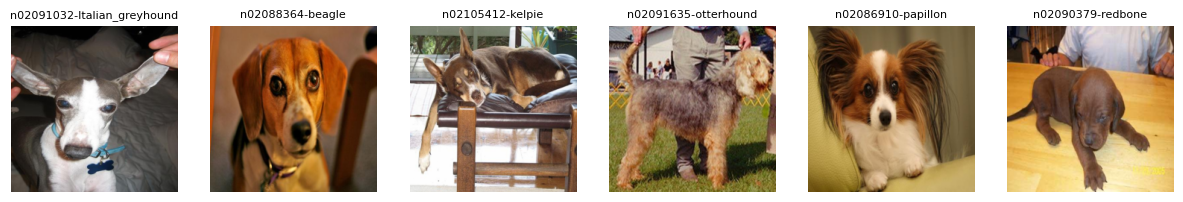

In [19]:
show_examples(basic_train_loader, basic_full_dataset.classes, num_images=6)

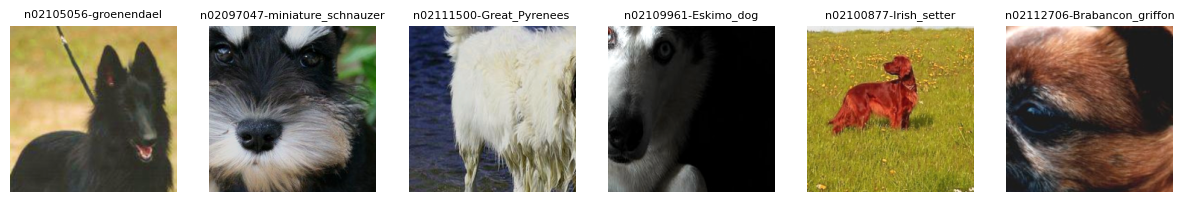

In [20]:
show_examples(aug_train_loader, aug_full_dataset.classes, num_images=6)

### 비교 실험용 데이터 확인 결과

`basic_train_loader`는 augmentation 없이 기본 전처리만 적용한 학습 데이터이다.  
`aug_train_loader`는 RandomResizedCrop, RandomHorizontalFlip, ColorJitter 등이 적용된 학습 데이터이다.  
`test_loader`는 두 모델이 동일하게 사용할 평가 데이터이다.

샘플 이미지를 확인한 결과, basic train 데이터는 비교적 원본 형태를 유지하고 있고, augmentation train 데이터는 crop, 색감 변화, 좌우 반전 등으로 이미지가 다양하게 변형되었다.

따라서 이제 같은 ResNet-50 모델 구조를 사용하여 augmentation 적용 여부에 따른 validation accuracy 차이를 비교할 수 있다.

In [21]:
import torch.nn as nn
import torchvision.models as models

num_classes = len(basic_full_dataset.classes)

resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
resnet50.fc = nn.Linear(resnet50.fc.in_features, num_classes)

aug_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
aug_resnet50.fc = nn.Linear(aug_resnet50.fc.in_features, num_classes)

print("ResNet-50 모델 2개 준비 완료")
print("클래스 수:", num_classes)

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:01<00:00, 81.8MB/s]


ResNet-50 모델 2개 준비 완료
클래스 수: 120


resnet50      → augmentation 없이 학습할 모델
aug_resnet50  → augmentation 적용 데이터로 학습할 모델

## ResNet-50 모델 준비

비교 실험을 위해 같은 구조의 ResNet-50 모델을 두 개 준비하였다.

첫 번째 모델은 augmentation을 적용하지 않은 `basic_train_loader`로 학습하고, 두 번째 모델은 augmentation을 적용한 `aug_train_loader`로 학습한다.

ResNet-50은 원래 ImageNet 1000개 클래스를 분류하도록 학습된 모델이므로, Stanford Dogs의 120개 클래스에 맞게 마지막 fully connected layer를 수정하였다.

In [22]:
import torch.optim as optim

EPOCH = 3
criterion = nn.CrossEntropyLoss()

def train(model, train_loader, test_loader, epochs, lr=0.001):
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)
    
    history = {
        'train_accuracy': [],
        'val_accuracy': []
    }

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        history['train_accuracy'].append(train_acc)

        print(f"Epoch [{epoch+1}/{epochs}], Train Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history['val_accuracy'].append(val_acc)

        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history

print("train 함수 준비 완료")

train 함수 준비 완료


중요한 점은 optimizer를 함수 안에서 만든다 것
모델이 2개이기 때문에 optimizer도 모델마다 따로 생성하는 게 안전함

In [26]:
%%time

history_resnet50_no_aug = train(
    resnet50,
    basic_train_loader,
    test_loader,
    EPOCH
)

Epoch [1/3], Train Accuracy: 80.68%
Validation Accuracy: 80.53%
Epoch [2/3], Train Accuracy: 81.93%
Validation Accuracy: 80.82%
Epoch [3/3], Train Accuracy: 83.01%
Validation Accuracy: 81.87%
CPU times: user 14min 25s, sys: 4.2 s, total: 14min 29s
Wall time: 10min 37s


### No Augmentation 모델 학습 결과

augmentation을 적용하지 않은 `basic_train_loader`로 ResNet-50 모델을 3 epoch 동안 학습하였다.

학습 결과는 다음과 같다.

- Epoch 1: Train Accuracy 80.68%, Validation Accuracy 80.53%
- Epoch 2: Train Accuracy 81.93%, Validation Accuracy 80.82%
- Epoch 3: Train Accuracy 83.01%, Validation Accuracy 81.87%

학습이 진행될수록 train accuracy가 상승하였고, validation accuracy도 약 81.87%까지 도달하였다.  
이는 ImageNet으로 사전학습된 ResNet-50 모델이 Stanford Dogs 데이터셋의 견종 분류 특징을 빠르게 학습하고 있음을 의미한다.

이 결과는 이후 augmentation을 적용한 모델과 비교하기 위한 기준 성능으로 사용한다.

In [1]:
print("aug_train_loader:", aug_train_loader)
print("test_loader:", test_loader)
print("EPOCH:", EPOCH)
print("num_classes:", len(basic_full_dataset.classes))

NameError: name 'aug_train_loader' is not defined

In [2]:
import os
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim

import torchvision.transforms as transforms
import torchvision.models as models

from torchvision.datasets import ImageFolder
from torch.utils.data import DataLoader, random_split, Subset

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

Using device: cuda


In [3]:
!ls -lh ~/work/data_augmentation/data
!ls ~/work/data_augmentation/data/Images | head
!find ~/work/data_augmentation/data/Images -type f | wc -l

total 1.5G
drwxrwsr-x 122 jovyan users 4.0K Oct  9  2011 Images
-rw-rw-r--   1 jovyan users 757M Oct 20  2011 images.tar
-rw-rw-r--   1 jovyan users 757M Oct 20  2011 images.tar.1
n02085620-Chihuahua
n02085782-Japanese_spaniel
n02085936-Maltese_dog
n02086079-Pekinese
n02086240-Shih-Tzu
n02086646-Blenheim_spaniel
n02086910-papillon
n02087046-toy_terrier
n02087394-Rhodesian_ridgeback
n02088094-Afghan_hound
20580


In [4]:
basic_train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

aug_train_transform = transforms.Compose([
    transforms.RandomResizedCrop(224),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.ColorJitter(
        brightness=0.2,
        contrast=0.2,
        saturation=0.2,
        hue=0.05
    ),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

test_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.5, 0.5, 0.5],
        std=[0.5, 0.5, 0.5]
    )
])

print("transform 3종 준비 완료")

transform 3종 준비 완료


In [5]:
dataset_dir = os.path.expanduser("~/work/data_augmentation/data/Images/")

basic_full_dataset = ImageFolder(root=dataset_dir, transform=basic_train_transform)
aug_full_dataset = ImageFolder(root=dataset_dir, transform=aug_train_transform)
test_full_dataset = ImageFolder(root=dataset_dir, transform=test_transform)

print("전체 데이터 수:", len(basic_full_dataset))
print("클래스 수:", len(basic_full_dataset.classes))
print("클래스 예시:", basic_full_dataset.classes[:5])

전체 데이터 수: 20580
클래스 수: 120
클래스 예시: ['n02085620-Chihuahua', 'n02085782-Japanese_spaniel', 'n02085936-Maltese_dog', 'n02086079-Pekinese', 'n02086240-Shih-Tzu']


In [6]:
total_size = len(basic_full_dataset)
train_size = int(0.583 * total_size)
test_size = total_size - train_size

generator = torch.Generator().manual_seed(42)

basic_train_split, basic_test_split = random_split(
    basic_full_dataset,
    [train_size, test_size],
    generator=generator
)

train_indices = basic_train_split.indices
test_indices = basic_test_split.indices

basic_train_dataset = Subset(basic_full_dataset, train_indices)
aug_train_dataset = Subset(aug_full_dataset, train_indices)
test_dataset = Subset(test_full_dataset, test_indices)

print("Basic train 데이터 수:", len(basic_train_dataset))
print("Aug train 데이터 수:", len(aug_train_dataset))
print("Test 데이터 수:", len(test_dataset))

Basic train 데이터 수: 11998
Aug train 데이터 수: 11998
Test 데이터 수: 8582


In [7]:
batch_size = 32

basic_train_loader = DataLoader(
    basic_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

aug_train_loader = DataLoader(
    aug_train_dataset,
    batch_size=batch_size,
    shuffle=True
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)

print("DataLoader 재생성 완료")
print("Basic train batches:", len(basic_train_loader))
print("Aug train batches:", len(aug_train_loader))
print("Test batches:", len(test_loader))

DataLoader 재생성 완료
Basic train batches: 375
Aug train batches: 375
Test batches: 269


In [8]:
print("aug_train_loader:", aug_train_loader)
print("test_loader:", test_loader)
print("num_classes:", len(basic_full_dataset.classes))

aug_train_loader: <torch.utils.data.dataloader.DataLoader object at 0x7f7bd17159a0>
test_loader: <torch.utils.data.dataloader.DataLoader object at 0x7f7bd125d0d0>
num_classes: 120


In [9]:
EPOCH = 3
print("EPOCH:", EPOCH)

EPOCH: 3


In [10]:
history_resnet50_no_aug = {
    "train_accuracy": [80.68, 81.93, 83.01],
    "val_accuracy": [80.53, 80.82, 81.87]
}

print("No Augmentation history 복구 완료")

No Augmentation history 복구 완료


In [11]:
print("train:", train)

NameError: name 'train' is not defined

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim

criterion = nn.CrossEntropyLoss()

def train(model, train_loader, test_loader, epochs, lr=0.001):
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    history = {
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)

            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            total += labels.size(0)
            correct += predicted.eq(labels).sum().item()

        train_acc = 100. * correct / total
        history["train_accuracy"].append(train_acc)

        print(f"Epoch [{epoch+1}/{epochs}], Train Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history["val_accuracy"].append(val_acc)

        print(f"Validation Accuracy: {val_acc:.2f}%")

    return history

print("train 함수 준비 완료")

train 함수 준비 완료


In [13]:
device = "cuda" if torch.cuda.is_available() else "cpu"
print("device:", device)

device: cuda


In [14]:
print("aug_train_loader:", aug_train_loader)
print("test_loader:", test_loader)
print("num_classes:", len(basic_full_dataset.classes))

aug_train_loader: <torch.utils.data.dataloader.DataLoader object at 0x7f7bd17159a0>
test_loader: <torch.utils.data.dataloader.DataLoader object at 0x7f7bd125d0d0>
num_classes: 120


In [15]:
import torchvision.models as models

aug_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

aug_resnet50.fc = nn.Linear(
    aug_resnet50.fc.in_features,
    len(basic_full_dataset.classes)
)

print("Augmentation ResNet-50 준비 완료")

Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/jovyan/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


100%|██████████| 97.8M/97.8M [00:00<00:00, 182MB/s]


Augmentation ResNet-50 준비 완료


In [16]:
%%time

history_resnet50_aug = train(
    aug_resnet50,
    aug_train_loader,
    test_loader,
    EPOCH
)

Epoch [1/3], Train Accuracy: 4.73%
Validation Accuracy: 15.66%
Epoch [2/3], Train Accuracy: 21.33%
Validation Accuracy: 36.68%
Epoch [3/3], Train Accuracy: 34.90%
Validation Accuracy: 50.89%
CPU times: user 20min 19s, sys: 7.94 s, total: 20min 27s
Wall time: 13min 42s


In [17]:
print(history_resnet50_no_aug)
print(history_resnet50_aug)

{'train_accuracy': [80.68, 81.93, 83.01], 'val_accuracy': [80.53, 80.82, 81.87]}
{'train_accuracy': [4.725787631271879, 21.328554759126522, 34.89748291381897], 'val_accuracy': [15.66068515497553, 36.68142624096947, 50.88557445816826]}


### With Augmentation 모델 학습 결과

augmentation을 적용한 `aug_train_loader`로 ResNet-50 모델을 3 epoch 동안 학습하였다.

이 데이터에는 RandomResizedCrop, RandomHorizontalFlip, ColorJitter 등이 적용되어 있다.  
따라서 모델은 원본 이미지뿐만 아니라 위치, 방향, 색감이 변형된 이미지를 함께 학습하였다.

학습 결과는 다음과 같다.

- Epoch 1: Train Accuracy 4.73%, Validation Accuracy 15.66%
- Epoch 2: Train Accuracy 21.33%, Validation Accuracy 36.68%
- Epoch 3: Train Accuracy 34.90%, Validation Accuracy 50.89%

augmentation을 적용한 모델은 augmentation을 적용하지 않은 모델보다 train accuracy와 validation accuracy가 낮게 나타났다.  
이는 augmentation이 학습 이미지를 더 다양하고 어렵게 만들기 때문에, 짧은 epoch에서는 학습 속도가 느리게 보일 수 있기 때문이다.

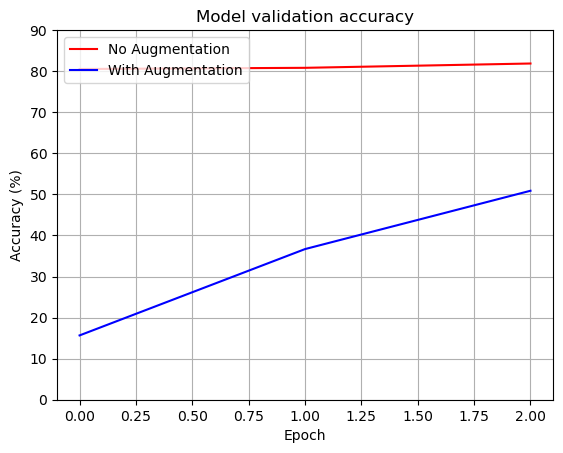

In [18]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')

plt.title('Model validation accuracy')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.ylim(0, 90)

plt.show()

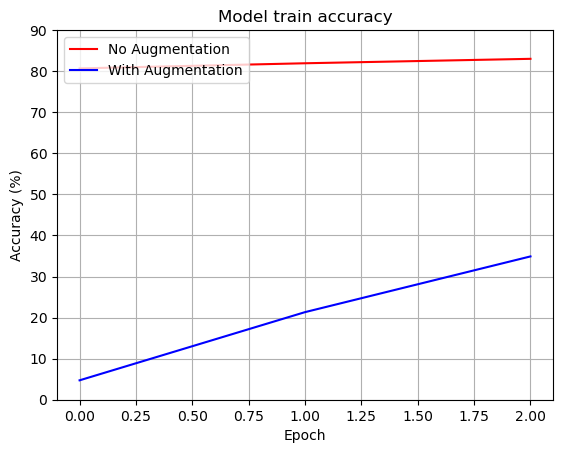

In [19]:
plt.plot(history_resnet50_no_aug['train_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['train_accuracy'], 'b', label='With Augmentation')

plt.title('Model train accuracy')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.ylim(0, 90)

plt.show()

### Augmentation 적용 여부에 따른 성능 비교표

| 실험 구분 | Epoch | 최종 Train Accuracy | 최종 Validation Accuracy | 해석 |
|---|---:|---:|---:|---|
| No Augmentation | 3 | 83.01% | 81.87% | 기본 전처리만 적용한 기준 모델 |
| With Augmentation | 3 | 34.90% | 50.89% | RandomResizedCrop, RandomHorizontalFlip, ColorJitter 적용 |

두 모델은 같은 ResNet-50 구조를 사용하였고, 동일한 test_loader로 평가하였다.  
차이는 train 데이터에 augmentation을 적용했는지 여부이다.

### Validation Accuracy 비교 결과 해석

이번 실험에서는 No Augmentation 모델이 3 epoch 기준 validation accuracy 81.87%를 기록하였다.  
반면 With Augmentation 모델은 3 epoch 기준 validation accuracy 50.89%를 기록하였다.

짧은 epoch 기준에서는 augmentation을 적용하지 않은 모델이 더 높은 성능을 보였다.  
이는 augmentation이 학습 이미지를 무작위로 crop하고, 좌우 반전하고, 색감을 변화시키기 때문에 모델 입장에서는 더 어려운 데이터를 학습하게 되기 때문이다.

따라서 augmentation 모델은 초반 학습 속도가 느리게 나타날 수 있다.  
하지만 augmentation은 단기적으로 정확도를 즉시 높이는 기술이라기보다, 충분히 학습했을 때 과적합을 줄이고 다양한 입력 상황에 대응하도록 돕는 일반화 전략이다.

이번 실험은 3 epoch로 짧게 수행되었기 때문에 augmentation의 장기적인 효과를 단정하기는 어렵다.  
더 정확한 비교를 위해서는 epoch 수를 늘리거나, learning rate와 augmentation 강도를 조정하여 추가 실험을 진행할 필요가 있다.

### 한 줄 요약

3 epoch의 짧은 실험에서는 No Augmentation 모델의 성능이 더 높았지만, augmentation은 학습 데이터를 더 어렵고 다양하게 만들어 장기적으로 일반화 성능을 높이기 위한 전략이다.

## 3. 심화 기법: CutMix Augmentation

CutMix는 두 이미지를 섞는 심화 augmentation 방법이다.  
한 이미지의 일부 영역을 잘라내고, 그 영역에 다른 이미지의 일부를 붙여 넣는다.

예를 들어 이미지 A의 일부 영역에 이미지 B의 일부를 삽입하면, 새 이미지는 A와 B의 정보를 함께 가진다.  
따라서 라벨도 하나만 사용하는 것이 아니라, 섞인 면적 비율에 따라 두 라벨을 함께 사용한다.

CutMix는 단순히 이미지를 지우는 Cutout과 달리, 지운 영역을 다른 이미지의 유용한 정보로 채운다.  
또한 Mixup처럼 라벨을 섞지만, 이미지 전체를 흐릿하게 섞는 것이 아니라 특정 영역을 잘라 붙이므로 지역 정보가 비교적 자연스럽게 유지된다.

### 한 줄 요약

CutMix는 두 이미지의 일부 영역을 잘라 섞고, 섞인 면적 비율에 따라 라벨도 함께 섞는 augmentation 기법이다.

In [20]:
def show_tensor_image(img_tensor, title=None):
    img = img_tensor.clone().detach().cpu()
    
    # Normalize(mean=0.5, std=0.5)를 되돌림
    img = img * 0.5 + 0.5
    
    # PyTorch: (C, H, W) → matplotlib: (H, W, C)
    img = img.permute(1, 2, 0).numpy()
    img = np.clip(img, 0, 1)

    plt.imshow(img)
    if title is not None:
        plt.title(title)
    plt.axis("off")
    plt.show()

print("이미지 시각화 함수 준비 완료")

이미지 시각화 함수 준비 완료


image_a shape: torch.Size([3, 224, 224])
image_b shape: torch.Size([3, 224, 224])
label_a: 50
label_b: 8


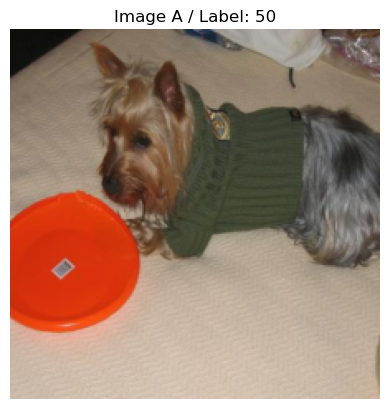

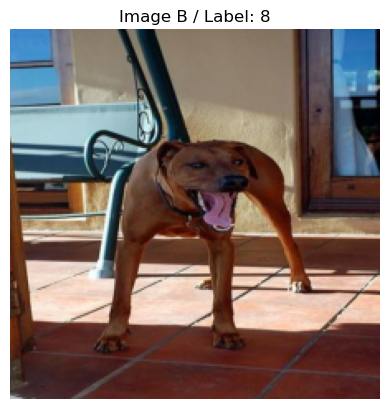

In [22]:
images, labels = next(iter(basic_train_loader))

image_a = images[0]
image_b = images[1]

label_a = labels[0].item()
label_b = labels[1].item()

print("image_a shape:", image_a.shape)
print("image_b shape:", image_b.shape)
print("label_a:", label_a)
print("label_b:", label_b)

show_tensor_image(image_a, title=f"Image A / Label: {label_a}")
show_tensor_image(image_b, title=f"Image B / Label: {label_b}")

CutMix를 하기 위해 학습 데이터 배치에서 이미지 2장을 가져온다.

In [23]:
def get_clip_box(image_a, image_b):
    # image.shape = (C, H, W)
    image_size_x = image_a.shape[2]  # width
    image_size_y = image_a.shape[1]  # height

    # box 중심점 랜덤 선택
    x = torch.randint(0, image_size_x, (1,)).item()
    y = torch.randint(0, image_size_y, (1,)).item()

    # box 크기 랜덤 선택
    width = max(1, int(image_size_x * torch.sqrt(1 - torch.rand(1)).item()))
    height = max(1, int(image_size_y * torch.sqrt(1 - torch.rand(1)).item()))

    # 이미지 밖으로 나가지 않게 좌표 조정
    x_min = max(0, x - width // 2)
    y_min = max(0, y - height // 2)
    x_max = min(image_size_x, x + width // 2 + 1)
    y_max = min(image_size_y, y + height // 2 + 1)

    return x_min, y_min, x_max, y_max


x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

print("x:", x_min, x_max)
print("y:", y_min, y_max)

x: 14 189
y: 0 146


get_clip_box()는 이미지 안에서 다른 이미지를 붙일 랜덤 사각형 영역을 만든다.

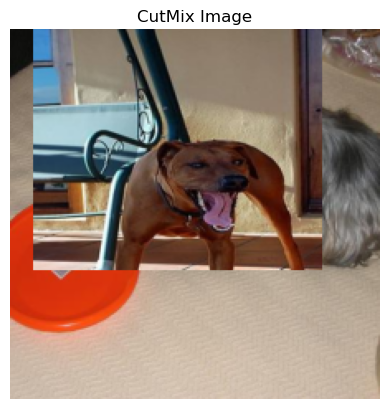

In [24]:
def mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max):
    mixed_img = image_a.clone()

    # image_a의 일부 영역을 image_b의 같은 위치 영역으로 교체
    mixed_img[:, y_min:y_max, x_min:x_max] = image_b[:, y_min:y_max, x_min:x_max]

    return mixed_img


mixed_img = mix_2_images(image_a, image_b, x_min, y_min, x_max, y_max)

show_tensor_image(mixed_img, title="CutMix Image")

In [26]:
def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, image_shape, num_classes=120):
    # image_shape = (C, H, W)
    image_size_y = image_shape[1]
    image_size_x = image_shape[2]

    box_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y

    ratio_b = box_area / total_area
    ratio_a = 1 - ratio_b

    label_a_onehot = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    label_b_onehot = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    mixed_label = ratio_a * label_a_onehot + ratio_b * label_b_onehot

    return mixed_label, ratio_a, ratio_b


mixed_label, ratio_a, ratio_b = mix_2_labels(
    label_a,
    label_b,
    x_min,
    y_min,
    x_max,
    y_max,
    image_a.shape,
    num_classes=len(basic_full_dataset.classes)
)

print("Image A label ratio:", ratio_a)
print("Image B label ratio:", ratio_b)
print("mixed_label shape:", mixed_label.shape)
print("mixed_label sum:", mixed_label.sum())

NameError: name 'F' is not defined

In [27]:
import torch
import torch.nn.functional as F

print("torch와 F 준비 완료")

torch와 F 준비 완료


In [28]:
label_a_onehot = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
label_b_onehot = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

NameError: name 'num_classes' is not defined

In [29]:
num_classes = len(basic_full_dataset.classes)

print("num_classes:", num_classes)

num_classes: 120


In [30]:
def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, image_shape, num_classes=120):
    # image_shape = (C, H, W)
    image_size_y = image_shape[1]
    image_size_x = image_shape[2]

    box_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y

    ratio_b = box_area / total_area
    ratio_a = 1 - ratio_b

    label_a_onehot = F.one_hot(
        torch.tensor(label_a),
        num_classes=num_classes
    ).float()

    label_b_onehot = F.one_hot(
        torch.tensor(label_b),
        num_classes=num_classes
    ).float()

    mixed_label = ratio_a * label_a_onehot + ratio_b * label_b_onehot

    return mixed_label, ratio_a, ratio_b

print("mix_2_labels 함수 준비 완료")

mix_2_labels 함수 준비 완료


In [31]:
num_classes = len(basic_full_dataset.classes)

mixed_label, ratio_a, ratio_b = mix_2_labels(
    label_a,
    label_b,
    x_min,
    y_min,
    x_max,
    y_max,
    image_a.shape,
    num_classes=num_classes
)

print("Image A label ratio:", ratio_a)
print("Image B label ratio:", ratio_b)
print("mixed_label shape:", mixed_label.shape)
print("mixed_label sum:", mixed_label.sum())

Image A label ratio: 0.4907924107142857
Image B label ratio: 0.5092075892857143
mixed_label shape: torch.Size([120])
mixed_label sum: tensor(1.)


처음 오류:
F가 정의되지 않음
→ import torch.nn.functional as F 필요

두 번째 오류:
num_classes가 정의되지 않음
→ num_classes = len(basic_full_dataset.classes) 필요

In [32]:
import torch
import torch.nn.functional as F

num_classes = len(basic_full_dataset.classes)

print("F 준비 완료")
print("num_classes:", num_classes)

F 준비 완료
num_classes: 120


In [33]:
def mix_2_labels(label_a, label_b, x_min, y_min, x_max, y_max, image_shape, num_classes=120):
    image_size_y = image_shape[1]
    image_size_x = image_shape[2]

    box_area = (x_max - x_min) * (y_max - y_min)
    total_area = image_size_x * image_size_y

    ratio_b = box_area / total_area
    ratio_a = 1 - ratio_b

    label_a_onehot = F.one_hot(torch.tensor(label_a), num_classes=num_classes).float()
    label_b_onehot = F.one_hot(torch.tensor(label_b), num_classes=num_classes).float()

    mixed_label = ratio_a * label_a_onehot + ratio_b * label_b_onehot

    return mixed_label, ratio_a, ratio_b

In [34]:
mixed_label, ratio_a, ratio_b = mix_2_labels(
    label_a,
    label_b,
    x_min,
    y_min,
    x_max,
    y_max,
    image_a.shape,
    num_classes=num_classes
)

print("Image A label ratio:", ratio_a)
print("Image B label ratio:", ratio_b)
print("mixed_label shape:", mixed_label.shape)
print("mixed_label sum:", mixed_label.sum())

Image A label ratio: 0.4907924107142857
Image B label ratio: 0.5092075892857143
mixed_label shape: torch.Size([120])
mixed_label sum: tensor(1.)


In [35]:
def cutmix(images, labels, num_classes=120):
    batch_size, C, H, W = images.shape

    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i].item()

        # batch 안에서 랜덤하게 다른 이미지 선택
        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j].item()

        # bounding box 생성
        x_min, y_min, x_max, y_max = get_clip_box(image_a, image_b)

        # 이미지 섞기
        mixed_img = mix_2_images(
            image_a,
            image_b,
            x_min,
            y_min,
            x_max,
            y_max
        )

        # 라벨 섞기
        mixed_label, ratio_a, ratio_b = mix_2_labels(
            label_a,
            label_b,
            x_min,
            y_min,
            x_max,
            y_max,
            image_a.shape,
            num_classes=num_classes
        )

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    mixed_imgs = torch.stack(mixed_imgs)
    mixed_labels = torch.stack(mixed_labels)

    return mixed_imgs, mixed_labels


print("CutMix batch 함수 준비 완료")

CutMix batch 함수 준비 완료


cutmix_imgs shape: torch.Size([32, 3, 224, 224])
cutmix_labels shape: torch.Size([32, 120])
cutmix label sum: tensor(1.)


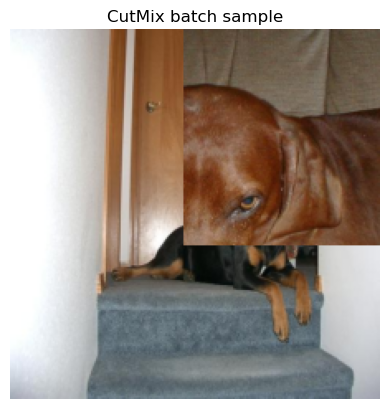

In [36]:
images, labels = next(iter(basic_train_loader))

cutmix_imgs, cutmix_labels = cutmix(
    images,
    labels,
    num_classes=len(basic_full_dataset.classes)
)

print("cutmix_imgs shape:", cutmix_imgs.shape)
print("cutmix_labels shape:", cutmix_labels.shape)
print("cutmix label sum:", cutmix_labels[0].sum())

show_tensor_image(cutmix_imgs[0], title="CutMix batch sample")

### CutMix 결과 관찰

CutMix를 적용하니 한 이미지의 일부 영역에 다른 이미지의 일부가 삽입되었다.  
이 방식은 단순히 이미지를 회전하거나 색을 바꾸는 augmentation과 달리, 두 이미지의 정보를 하나의 이미지 안에 함께 포함시킨다.

또한 라벨도 섞인 면적 비율에 따라 두 클래스의 비율을 함께 반영한다.  
이번 예시에서는 Image A 라벨 비율이 약 49.1%, Image B 라벨 비율이 약 50.9%로 계산되었다.

`mixed_label`의 shape는 `[120]`으로 Stanford Dogs의 120개 클래스를 의미하며, `mixed_label sum`이 1로 나타났으므로 soft label이 정상적으로 생성되었음을 확인하였다.

지금은 CutMix 라벨 섞기까지 성공했으니, 다음은 batch 전체에 CutMix를 적용하는 cutmix() 함수를 만들고 결과 이미지와 soft label shape를 확인하면 된다.

## 3. 심화 기법: Mixup Augmentation

Mixup은 두 이미지와 두 라벨을 일정 비율로 섞어 새로운 학습 데이터를 만드는 augmentation 방법이다.

CutMix는 한 이미지의 특정 영역을 잘라 다른 이미지의 영역으로 교체하지만, Mixup은 이미지 전체의 픽셀 값을 비율에 따라 섞는다.

예를 들어 이미지 A와 이미지 B를 0.7 : 0.3 비율로 섞는다면, 라벨도 A 0.7, B 0.3 비율로 섞는다.

Mixup은 구현이 비교적 간단하고, 모델이 두 클래스 사이의 중간적인 특징을 학습하도록 도와준다.  
다만 두 이미지가 전체적으로 겹치기 때문에 사람이 보기에는 다소 부자연스러운 이미지가 만들어질 수 있다.

### 한 줄 요약

Mixup은 두 이미지 전체와 두 라벨을 같은 비율로 선형 결합하여 새로운 학습 데이터를 만드는 augmentation 기법이다.

image_a shape: torch.Size([3, 224, 224])
image_b shape: torch.Size([3, 224, 224])
label_a: 105
label_b: 29


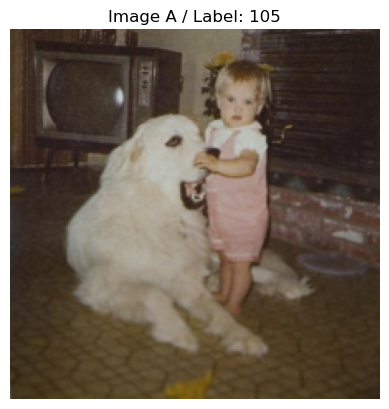

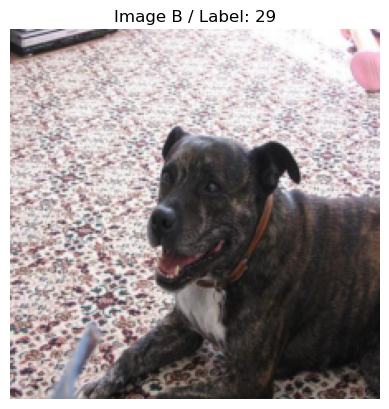

In [37]:
images, labels = next(iter(basic_train_loader))

image_a = images[0]
image_b = images[1]

label_a = labels[0].item()
label_b = labels[1].item()

print("image_a shape:", image_a.shape)
print("image_b shape:", image_b.shape)
print("label_a:", label_a)
print("label_b:", label_b)

show_tensor_image(image_a, title=f"Image A / Label: {label_a}")
show_tensor_image(image_b, title=f"Image B / Label: {label_b}")

In [38]:
def mixup_2_images(image_a, image_b, label_a, label_b, num_classes=120):
    # 0~1 사이의 랜덤 혼합 비율
    ratio = torch.rand(1).item()

    # 정수 라벨을 one-hot vector로 변환
    label_a_onehot = F.one_hot(
        torch.tensor(label_a),
        num_classes=num_classes
    ).float()

    label_b_onehot = F.one_hot(
        torch.tensor(label_b),
        num_classes=num_classes
    ).float()

    # 이미지와 라벨을 같은 비율로 섞기
    mixed_image = (1 - ratio) * image_a + ratio * image_b
    mixed_label = (1 - ratio) * label_a_onehot + ratio * label_b_onehot

    return mixed_image, mixed_label, ratio

print("mixup_2_images 함수 준비 완료")

mixup_2_images 함수 준비 완료


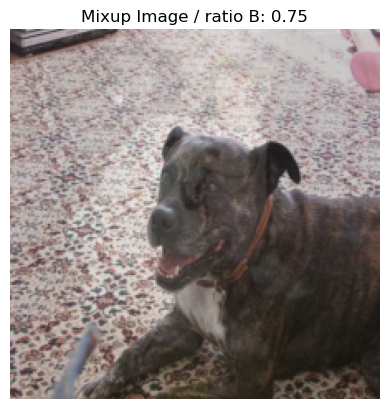

Image A label ratio: 0.24524468183517456
Image B label ratio: 0.7547553181648254
mixed_label shape: torch.Size([120])
mixed_label sum: tensor(1.)


In [39]:
mixed_img, mixed_label, ratio = mixup_2_images(
    image_a,
    image_b,
    label_a,
    label_b,
    num_classes=len(basic_full_dataset.classes)
)

show_tensor_image(mixed_img, title=f"Mixup Image / ratio B: {ratio:.2f}")

print("Image A label ratio:", 1 - ratio)
print("Image B label ratio:", ratio)
print("mixed_label shape:", mixed_label.shape)
print("mixed_label sum:", mixed_label.sum())

### Mixup 결과 관찰

Mixup을 적용하니 두 이미지가 투명하게 겹쳐진 것처럼 보였다.  
CutMix는 특정 사각형 영역만 교체하지만, Mixup은 이미지 전체의 픽셀 값을 비율에 따라 섞는다.

라벨도 이미지 혼합 비율과 같은 비율로 섞인다.  
예를 들어 이미지 A가 0.6, 이미지 B가 0.4 비율로 섞였다면 라벨도 A 0.6, B 0.4의 soft label이 된다.

이번 결과에서 `mixed_label`의 shape는 `[120]`으로 나타났고, 전체 합이 1이므로 soft label이 정상적으로 만들어졌음을 확인하였다.

In [40]:
def mixup(images, labels, num_classes=120):
    batch_size, C, H, W = images.shape

    mixed_imgs = []
    mixed_labels = []

    for i in range(batch_size):
        image_a = images[i]
        label_a = labels[i].item()

        # batch 안에서 랜덤하게 다른 이미지 선택
        j = torch.randint(0, batch_size, (1,)).item()
        image_b = images[j]
        label_b = labels[j].item()

        mixed_img, mixed_label, ratio = mixup_2_images(
            image_a,
            image_b,
            label_a,
            label_b,
            num_classes=num_classes
        )

        mixed_imgs.append(mixed_img)
        mixed_labels.append(mixed_label)

    mixed_imgs = torch.stack(mixed_imgs)
    mixed_labels = torch.stack(mixed_labels)

    return mixed_imgs, mixed_labels

print("Mixup batch 함수 준비 완료")

Mixup batch 함수 준비 완료


mixup_imgs shape: torch.Size([32, 3, 224, 224])
mixup_labels shape: torch.Size([32, 120])
mixup label sum: tensor(1.)


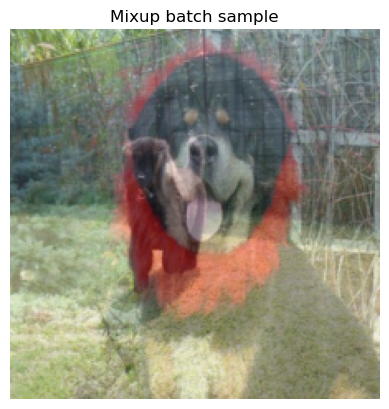

In [41]:
images, labels = next(iter(basic_train_loader))

mixup_imgs, mixup_labels = mixup(
    images,
    labels,
    num_classes=len(basic_full_dataset.classes)
)

print("mixup_imgs shape:", mixup_imgs.shape)
print("mixup_labels shape:", mixup_labels.shape)
print("mixup label sum:", mixup_labels[0].sum())

show_tensor_image(mixup_imgs[0], title="Mixup batch sample")

### CutMix와 Mixup 비교

CutMix와 Mixup은 모두 두 이미지와 두 라벨을 섞는 심화 augmentation 기법이다.

Mixup은 두 이미지 전체를 픽셀 단위로 부드럽게 섞는다.  
따라서 구현이 간단하지만, 두 이미지가 투명하게 겹쳐져 다소 부자연스럽게 보일 수 있다.

CutMix는 한 이미지의 일부 영역을 다른 이미지의 일부 영역으로 교체한다.  
따라서 Mixup보다 지역 정보가 더 자연스럽게 유지될 수 있고, 모델이 이미지의 특정 부분만 보는 것을 줄이는 데 도움을 줄 수 있다.

두 방법 모두 라벨을 one-hot label이 아니라 섞인 비율을 반영한 soft label로 만든다는 공통점이 있다.

In [42]:
def soft_cross_entropy(outputs, soft_targets):
    log_probs = torch.nn.functional.log_softmax(outputs, dim=1)
    loss = -(soft_targets * log_probs).sum(dim=1).mean()
    return loss

print("soft_cross_entropy 함수 준비 완료")

soft_cross_entropy 함수 준비 완료


### Soft Label Loss

CutMix와 Mixup은 두 이미지와 두 라벨을 섞기 때문에 정답 라벨이 하나의 클래스 번호가 아니라 여러 클래스의 비율을 가진 soft label이 된다.

일반적인 `CrossEntropyLoss`는 정답 라벨이 정수 클래스 인덱스일 때 사용한다.  
하지만 CutMix와 Mixup에서는 라벨이 soft label 형태이므로, soft label을 처리할 수 있는 loss 함수가 필요하다.

따라서 `log_softmax`와 soft target을 이용해 `soft_cross_entropy` 함수를 직접 구현하였다.

## CutMix와 Mixup 구현 결과 정리

이번 단계에서는 기본적인 image augmentation을 넘어, 두 이미지와 두 라벨을 함께 섞는 심화 augmentation 기법을 구현하였다.

CutMix는 한 이미지의 일부 영역을 다른 이미지의 일부 영역으로 교체하고, 교체된 면적 비율에 따라 라벨도 함께 섞는 방식이다.  
Mixup은 두 이미지 전체를 일정 비율로 선형 결합하고, 라벨도 같은 비율로 섞는 방식이다.

두 방법 모두 정답 라벨이 하나의 클래스 번호가 아니라 여러 클래스의 비율을 가진 soft label이 된다.  
따라서 일반적인 CrossEntropyLoss 대신 soft label을 처리할 수 있는 loss 함수가 필요하다.

In [43]:
def soft_cross_entropy(outputs, soft_targets):
    log_probs = torch.nn.functional.log_softmax(outputs, dim=1)
    loss = -(soft_targets * log_probs).sum(dim=1).mean()
    return loss

print("soft_cross_entropy 함수 준비 완료")

soft_cross_entropy 함수 준비 완료


In [44]:
images, labels = next(iter(basic_train_loader))

mixup_imgs, mixup_labels = mixup(
    images,
    labels,
    num_classes=len(basic_full_dataset.classes)
)

test_model = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)
test_model.fc = nn.Linear(
    test_model.fc.in_features,
    len(basic_full_dataset.classes)
)

test_model.to(device)

mixup_imgs = mixup_imgs.to(device)
mixup_labels = mixup_labels.to(device)

outputs = test_model(mixup_imgs)
loss = soft_cross_entropy(outputs, mixup_labels)

print("outputs shape:", outputs.shape)
print("loss:", loss.item())

outputs shape: torch.Size([32, 120])
loss: 4.871965408325195


soft label을 가진 Mixup/CutMix 데이터가 모델 출력과 함께 loss 계산에 들어갈 수 있는지 확인하는 단계다.

In [45]:
def train_with_cutmix(model, train_loader, test_loader, epochs, lr=0.001):
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    history = {
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            cutmix_imgs, cutmix_labels = cutmix(
                images,
                labels,
                num_classes=len(basic_full_dataset.classes)
            )

            cutmix_imgs = cutmix_imgs.to(device)
            cutmix_labels = cutmix_labels.to(device)

            optimizer.zero_grad()
            outputs = model(cutmix_imgs)
            loss = soft_cross_entropy(outputs, cutmix_labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            hard_labels = cutmix_labels.argmax(dim=1)

            total += hard_labels.size(0)
            correct += predicted.eq(hard_labels).sum().item()

        train_acc = 100. * correct / total
        history["train_accuracy"].append(train_acc)

        print(f"Epoch [{epoch+1}/{epochs}], CutMix Train Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history["val_accuracy"].append(val_acc)

        print(f"CutMix Validation Accuracy: {val_acc:.2f}%")

    return history

print("train_with_cutmix 함수 준비 완료")

train_with_cutmix 함수 준비 완료


CutMix 학습 함수는 원본 batch를 CutMix batch로 바꾼 뒤 soft label loss로 학습하는 함수다.

In [46]:
def train_with_mixup(model, train_loader, test_loader, epochs, lr=0.001):
    model.to(device)
    optimizer = optim.SGD(model.parameters(), lr=lr)

    history = {
        "train_accuracy": [],
        "val_accuracy": []
    }

    for epoch in range(epochs):
        model.train()
        correct = 0
        total = 0

        for images, labels in train_loader:
            mixup_imgs, mixup_labels = mixup(
                images,
                labels,
                num_classes=len(basic_full_dataset.classes)
            )

            mixup_imgs = mixup_imgs.to(device)
            mixup_labels = mixup_labels.to(device)

            optimizer.zero_grad()
            outputs = model(mixup_imgs)
            loss = soft_cross_entropy(outputs, mixup_labels)
            loss.backward()
            optimizer.step()

            _, predicted = outputs.max(1)
            hard_labels = mixup_labels.argmax(dim=1)

            total += hard_labels.size(0)
            correct += predicted.eq(hard_labels).sum().item()

        train_acc = 100. * correct / total
        history["train_accuracy"].append(train_acc)

        print(f"Epoch [{epoch+1}/{epochs}], Mixup Train Accuracy: {train_acc:.2f}%")

        model.eval()
        correct = 0
        total = 0

        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)

                _, predicted = outputs.max(1)
                total += labels.size(0)
                correct += predicted.eq(labels).sum().item()

        val_acc = 100. * correct / total
        history["val_accuracy"].append(val_acc)

        print(f"Mixup Validation Accuracy: {val_acc:.2f}%")

    return history

print("train_with_mixup 함수 준비 완료")

train_with_mixup 함수 준비 완료


Mixup 학습 함수는 이미지 전체와 라벨을 비율로 섞은 batch를 soft label loss로 학습하는 함수다.

In [47]:
EPOCH_ADV = 1
print("심화 augmentation 테스트 epoch:", EPOCH_ADV)

심화 augmentation 테스트 epoch: 1


In [48]:
cutmix_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

cutmix_resnet50.fc = nn.Linear(
    cutmix_resnet50.fc.in_features,
    len(basic_full_dataset.classes)
)

print("CutMix ResNet-50 준비 완료")

CutMix ResNet-50 준비 완료


In [49]:
%%time

history_resnet50_cutmix = train_with_cutmix(
    cutmix_resnet50,
    basic_train_loader,
    test_loader,
    EPOCH_ADV
)

Epoch [1/1], CutMix Train Accuracy: 2.12%
CutMix Validation Accuracy: 6.61%
CPU times: user 4min 47s, sys: 1.31 s, total: 4min 48s
Wall time: 3min 29s


In [50]:
mixup_resnet50 = models.resnet50(weights=models.ResNet50_Weights.IMAGENET1K_V1)

mixup_resnet50.fc = nn.Linear(
    mixup_resnet50.fc.in_features,
    len(basic_full_dataset.classes)
)

print("Mixup ResNet-50 준비 완료")

Mixup ResNet-50 준비 완료


In [51]:
%%time

history_resnet50_mixup = train_with_mixup(
    mixup_resnet50,
    basic_train_loader,
    test_loader,
    EPOCH_ADV
)

Epoch [1/1], Mixup Train Accuracy: 2.68%
Mixup Validation Accuracy: 9.68%
CPU times: user 4min 50s, sys: 1.46 s, total: 4min 51s
Wall time: 3min 30s


### Mixup 학습 결과

Mixup을 적용한 batch로 ResNet-50 모델을 1 epoch 동안 학습하였다.

Mixup은 두 이미지 전체를 일정 비율로 선형 결합하고, 라벨도 같은 비율로 섞는 augmentation 방법이다.  
CutMix와 마찬가지로 라벨이 soft label이 되므로 `soft_cross_entropy`를 사용하였다.

학습 결과는 다음과 같다.

- Epoch 1: Mixup Train Accuracy 2.68%
- Epoch 1: Mixup Validation Accuracy 9.68%
- Wall time: 약 3분 30초

이번 실험은 1 epoch만 수행했기 때문에 성능 자체보다는 Mixup이 학습 루프에 정상적으로 연결되는지 확인하는 데 의미가 있다.  
Mixup 역시 이미지와 라벨을 함께 섞기 때문에 초반 정확도는 낮게 나타날 수 있다.

### Augmentation 실험 결과 비교표

| 실험 구분 | Epoch | 최종 Train Accuracy | 최종 Validation Accuracy | 해석 |
|---|---:|---:|---:|---|
| No Augmentation | 3 | 83.01% | 81.87% | 기본 전처리만 적용한 기준 모델 |
| With Augmentation | 3 | 34.90% | 50.89% | RandomResizedCrop, Flip, ColorJitter 적용 |
| CutMix | 1 | 2.12% | 6.61% | 이미지 일부 영역과 라벨 비율을 섞는 심화 augmentation |
| Mixup | 1 | 2.68% | 9.68% | 이미지 전체와 라벨을 선형 결합하는 심화 augmentation |

CutMix와 Mixup은 1 epoch만 수행했기 때문에 앞선 3 epoch 실험과 직접적인 성능 비교를 하기는 어렵다.  
이번 단계에서는 심화 augmentation이 학습 루프에 정상적으로 연결되는지 확인하는 데 의미가 있다.

In [52]:
history_resnet50_cutmix = {
    "train_accuracy": [2.12],
    "val_accuracy": [6.61]
}

history_resnet50_mixup = {
    "train_accuracy": [2.68],
    "val_accuracy": [9.68]
}

print("CutMix/Mixup history 정리 완료")

CutMix/Mixup history 정리 완료


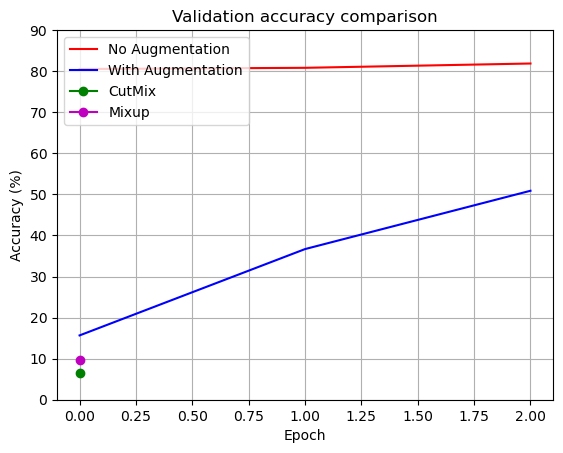

In [53]:
plt.plot(history_resnet50_no_aug['val_accuracy'], 'r', label='No Augmentation')
plt.plot(history_resnet50_aug['val_accuracy'], 'b', label='With Augmentation')
plt.plot(history_resnet50_cutmix['val_accuracy'], 'g', marker='o', label='CutMix')
plt.plot(history_resnet50_mixup['val_accuracy'], 'm', marker='o', label='Mixup')

plt.title('Validation accuracy comparison')
plt.ylabel('Accuracy (%)')
plt.xlabel('Epoch')
plt.legend(loc='upper left')
plt.grid(True)
plt.ylim(0, 90)

plt.show()

### 전체 Validation Accuracy 비교 해석

그래프는 No Augmentation, With Augmentation, CutMix, Mixup 실험의 validation accuracy를 비교한 것이다.

No Augmentation과 With Augmentation은 3 epoch 동안 학습하였고, CutMix와 Mixup은 1 epoch만 학습하였다.  
따라서 네 실험의 성능을 직접적으로 비교하기보다는, 각 augmentation 기법이 학습 루프에 정상적으로 연결되었는지를 확인하는 기록으로 해석해야 한다.

No Augmentation 모델은 3 epoch 기준 validation accuracy 81.87%를 기록하였다.  
With Augmentation 모델은 3 epoch 기준 validation accuracy 50.89%를 기록하였다.  
CutMix와 Mixup은 각각 1 epoch 기준 validation accuracy 6.61%, 9.68%를 기록하였다.

CutMix와 Mixup은 이미지와 라벨을 함께 섞는 심화 augmentation이기 때문에 학습 초반에는 정확도가 낮게 나타날 수 있다.  
특히 1 epoch만으로는 일반화 성능을 판단하기 어렵고, 충분한 epoch와 동일한 조건에서 반복 실험을 해야 더 정확한 비교가 가능하다.

## 실습 최종 정리

이번 실습에서는 Stanford Dogs Dataset을 활용하여 image augmentation을 모델 학습에 적용하였다.

먼저 augmentation을 적용하지 않은 데이터와 기본 augmentation을 적용한 데이터를 각각 ResNet-50으로 학습하여 성능을 비교하였다.  
그 결과 3 epoch 기준에서는 No Augmentation 모델이 더 높은 validation accuracy를 기록하였다.  
이는 augmentation이 학습 이미지를 더 다양하고 어렵게 만들기 때문에 짧은 epoch에서는 학습 속도가 느리게 나타날 수 있기 때문이다.

이후 CutMix와 Mixup을 구현하였다.  
CutMix는 한 이미지의 일부 영역을 다른 이미지의 일부 영역으로 교체하고, 섞인 면적 비율에 따라 라벨을 섞는 방법이다.  
Mixup은 두 이미지 전체를 일정 비율로 선형 결합하고, 라벨도 같은 비율로 섞는 방법이다.

CutMix와 Mixup은 모두 soft label을 생성하므로 일반적인 CrossEntropyLoss 대신 soft label을 처리할 수 있는 `soft_cross_entropy`를 사용하였다.  
이번 실습에서는 CutMix와 Mixup을 각각 1 epoch만 학습하여 학습 루프에 정상적으로 연결되는지 확인하였다.

정확한 성능 비교를 위해서는 모든 실험을 동일한 epoch 수, 동일한 optimizer 설정, 동일한 데이터 split 조건에서 반복적으로 수행해야 한다.

### 한 줄 요약

Image Augmentation은 학습 데이터를 다양하게 만들어 모델의 일반화 성능을 높이기 위한 전략이며, CutMix와 Mixup은 이미지뿐 아니라 라벨까지 섞는 심화 augmentation 기법이다.

## 전체 실험 결과 비교

| 실험 구분 | Epoch | Train Accuracy | Validation Accuracy | 주요 특징 |
|---|---:|---:|---:|---|
| No Augmentation | 3 | 83.01% | 81.87% | 기본 전처리만 적용 |
| With Augmentation | 3 | 34.90% | 50.89% | RandomResizedCrop, Flip, ColorJitter 적용 |
| CutMix | 1 | 2.12% | 6.61% | 이미지 일부 영역과 라벨 비율을 섞음 |
| Mixup | 1 | 2.68% | 9.68% | 이미지 전체와 라벨을 선형 결합 |

No Augmentation과 With Augmentation은 3 epoch 동안 학습하였고, CutMix와 Mixup은 1 epoch만 학습하였다.  
따라서 네 실험의 성능을 직접적으로 비교하기보다는, 각 augmentation 기법이 모델 학습에 어떻게 연결되는지 확인하는 실습으로 해석해야 한다.

## 실험 결과 해석

이번 실험에서는 Stanford Dogs Dataset을 사용하여 ResNet-50 모델에 다양한 image augmentation을 적용하였다.

먼저 augmentation을 적용하지 않은 모델은 3 epoch 기준 validation accuracy 81.87%를 기록하였다.  
반면 기본 augmentation을 적용한 모델은 3 epoch 기준 validation accuracy 50.89%를 기록하였다.

짧은 epoch에서는 augmentation을 적용한 모델의 성능이 낮게 나타났다.  
이는 augmentation이 학습 이미지를 무작위로 자르고, 뒤집고, 색상을 변화시키기 때문에 모델이 더 어려운 데이터를 학습하게 되기 때문이다.

CutMix와 Mixup은 각각 1 epoch만 학습하였다.  
두 기법은 이미지와 라벨을 함께 섞는 심화 augmentation이므로 초반 정확도는 낮게 나타날 수 있다.  
이번 실험에서는 성능 우열을 판단하기보다는 CutMix와 Mixup이 학습 루프에 정상적으로 연결되는지 확인하는 데 의미가 있다.

## 한계점과 개선 방법

### 한계점

이번 실험은 epoch 수가 충분하지 않다는 한계가 있다.  
No Augmentation과 With Augmentation은 3 epoch, CutMix와 Mixup은 1 epoch만 학습했기 때문에 네 실험을 동일한 조건에서 직접 비교하기 어렵다.

또한 augmentation 강도와 learning rate가 최적화되지 않았다.  
RandomResizedCrop이나 ColorJitter가 너무 강하게 적용되면 이미지의 중요한 특징이 사라질 수 있고, CutMix와 Mixup 역시 학습 초반에는 모델이 이미지를 이해하기 어렵게 만들 수 있다.

### 개선 방법

더 정확한 비교를 위해서는 모든 실험을 동일한 epoch 수로 수행해야 한다.  
예를 들어 No Augmentation, Basic Augmentation, CutMix, Mixup을 모두 10 epoch 이상 학습한 뒤 validation accuracy를 비교하는 것이 좋다.

또한 learning rate, batch size, augmentation 강도를 조절하며 추가 실험을 진행할 필요가 있다.  
특히 augmentation은 단기적인 정확도 향상보다 장기적인 일반화 성능 향상을 목표로 하므로, 충분한 학습 시간이 필요하다.

## 예상 문제와 풀이

### 문제 1. Data Augmentation을 사용하는 이유는 무엇인가?

정답:  
Data Augmentation은 기존 데이터를 변형하여 학습 데이터의 다양성을 높이기 위해 사용한다.  
이를 통해 모델이 특정 이미지에 과적합되는 것을 줄이고, 실제 환경에서 더 다양한 입력에 대응할 수 있도록 돕는다.

---

### 문제 2. train 데이터에는 augmentation을 적용하지만 test 데이터에는 일반적으로 적용하지 않는 이유는 무엇인가?

정답:  
train 데이터에는 모델이 다양한 상황을 학습하도록 augmentation을 적용한다.  
하지만 test 데이터는 모델의 실제 성능을 공정하게 평가해야 하므로 랜덤 변형을 적용하지 않는다.  
test 데이터에는 Resize, ToTensor, Normalize처럼 고정된 전처리만 적용하는 것이 일반적이다.

---

### 문제 3. CutMix와 Mixup의 차이는 무엇인가?

정답:  
CutMix는 한 이미지의 일부 영역을 다른 이미지의 일부 영역으로 교체하는 방법이다.  
Mixup은 두 이미지 전체를 일정 비율로 섞는 방법이다.  
둘 다 라벨도 함께 섞는다는 공통점이 있지만, CutMix는 지역 정보를 유지하고 Mixup은 전체 이미지를 부드럽게 섞는다는 차이가 있다.

---

### 문제 4. CutMix와 Mixup에서 soft label이 필요한 이유는 무엇인가?

정답:  
CutMix와 Mixup은 두 이미지가 섞여 하나의 학습 이미지가 만들어진다.  
따라서 정답 라벨도 하나의 클래스만 가리킬 수 없고, 두 이미지가 섞인 비율에 따라 함께 표현되어야 한다.  
이처럼 여러 클래스의 비율이 들어간 라벨을 soft label이라고 한다.

---

### 문제 5. 이번 실험에서 augmentation 모델의 성능이 낮게 나온 이유는 무엇인가?

정답:  
이번 실험은 epoch 수가 짧았기 때문이다.  
augmentation은 이미지를 더 다양하고 어렵게 만들어 모델의 학습 난이도를 높인다.  
따라서 초반에는 정확도가 낮게 나올 수 있다.  
하지만 충분히 오래 학습하면 과적합을 줄이고 일반화 성능을 높이는 데 도움이 될 수 있다.

## 최종 요약

이번 실습에서는 Stanford Dogs Dataset을 활용하여 image augmentation을 모델 학습에 적용하였다.

기본 실험에서는 augmentation을 적용하지 않은 모델과 RandomResizedCrop, RandomHorizontalFlip, ColorJitter를 적용한 모델을 비교하였다.  
3 epoch 기준으로는 No Augmentation 모델이 더 높은 validation accuracy를 기록하였다.  
그러나 이는 augmentation이 효과가 없다는 의미가 아니라, 짧은 학습에서는 augmentation이 학습 난이도를 높이기 때문에 성능이 낮게 나타날 수 있음을 의미한다.

심화 실험에서는 CutMix와 Mixup을 구현하였다.  
CutMix는 이미지의 일부 영역을 다른 이미지로 교체하고, Mixup은 두 이미지를 전체적으로 섞는다.  
두 방법 모두 라벨도 함께 섞기 때문에 soft label과 soft_cross_entropy가 필요하다.

이번 실습의 핵심은 image augmentation이 단순히 데이터를 늘리는 기술이 아니라, 모델이 더 다양한 상황을 학습하도록 돕는 일반화 전략이라는 점이다.